# 🌀 What Is a Rotation Curve?
### EPS Research High-School Exploration Track — Ages 12-14

Imagine spinning a bicycle wheel. The outside of the wheel moves faster
than the inside — they have to travel farther in the same time.

But galaxies are **weird**! Their stars all spin at about the **same speed**,
no matter how far from the center. This is called a **flat rotation curve**,
and it's one of the biggest mysteries in science!

Let's look at a real galaxy rotation curve. We'll use **DDO161**,
a small galaxy about 7.5 million light-years away.

In [1]:
# ── Colab setup: auto-download corpus from Zenodo ─────────────
import os, sys
IN_COLAB = 'google.colab' in sys.modules
if IN_COLAB:
    import urllib.request
    CORPORA = {
        'rotation_curve_corpus_v7.json': 'https://zenodo.org/records/19563417/files/rotation_curve_corpus_v7.json',
        'high_z_kinematic_corpus_Z1.json': 'https://zenodo.org/records/20369286/files/high_z_kinematic_corpus_Z1.json',
        'dwarf_irregular_corpus_v1.json': 'https://zenodo.org/records/20320362/files/dwarf_irregular_corpus_v1.json',
    }
    for filename, url in CORPORA.items():
        if not os.path.exists(filename):
            print(f"Downloading {filename}...")
            urllib.request.urlretrieve(url, filename)
            print(f"  ✓ {filename}")
        else:
            print(f"  Already present: {filename}")
    print("Ready.")
else:
    print("Running locally — corpus files loaded from working directory.")


Running locally — corpus files loaded from working directory.


In [2]:
import json
import matplotlib.pyplot as plt

with open('rotation_curve_corpus_v7.json') as f:
    corpus = json.load(f)

# Find DDO161
galaxy = next(g for g in corpus['galaxies'] if g['galaxy'] == 'DDO161')

# Get the rotation data
data   = galaxy['data']
radius = [point['Rad']  for point in data]   # distance from center (kpc)
speed  = [point['Vobs'] for point in data]   # speed of stars (km/s)

print(f"Galaxy: {galaxy['galaxy']}")
print(f"Distance from Earth: {galaxy['distance_mpc']} Megaparsecs")
print(f"  (that's about {galaxy['distance_mpc'] * 3.26:.0f} million light-years!)")
print(f"Number of measurements: {len(data)}")
print()
print("First few measurements:")
print(f"  {'Radius (kpc)':>14}  {'Speed (km/s)':>12}")
for r, s in zip(radius[:5], speed[:5]):
    print(f"  {r:>14.2f}  {s:>12.1f}")

Galaxy: DDO161
Distance from Earth: 7.5 Megaparsecs
  (that's about 24 million light-years!)
Number of measurements: 31

First few measurements:
    Radius (kpc)  Speed (km/s)
            0.60          16.0
            0.73          16.6
            0.85          18.6
            0.98          20.0
            1.07          21.4


/tmp/ipykernel_130217/3757701538.py:14: UserWarning: Glyph 127744 (\N{CYCLONE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_130217/3757701538.py:15: UserWarning: Glyph 127744 (\N{CYCLONE}) missing from font(s) DejaVu Sans.
  plt.savefig('hs_a_02_rotation_curve.png', dpi=150, bbox_inches='tight')
/home/david/jupyterlab/venv/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 127744 (\N{CYCLONE}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


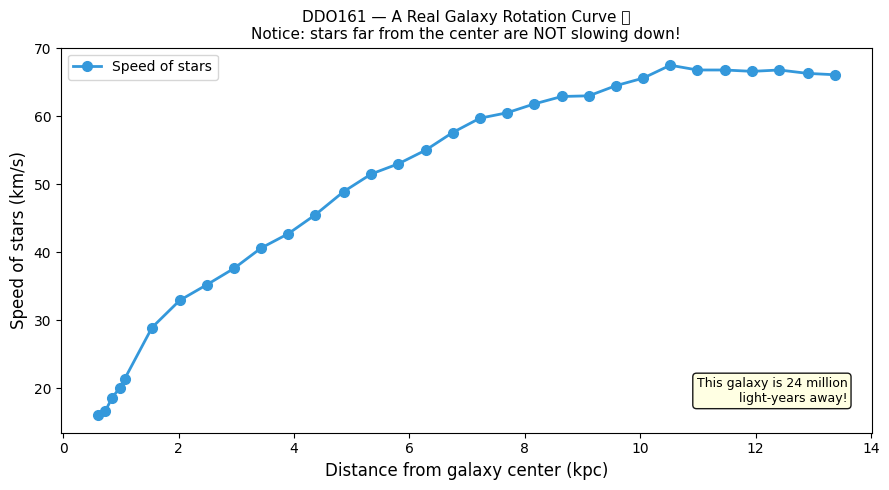

In [3]:
fig, ax = plt.subplots(figsize=(9, 5))
ax.plot(radius, speed, 'o-', color='#3498db', linewidth=2, markersize=7,
        label='Speed of stars')
ax.set_xlabel('Distance from galaxy center (kpc)', fontsize=12)
ax.set_ylabel('Speed of stars (km/s)', fontsize=12)
ax.set_title('DDO161 — A Real Galaxy Rotation Curve 🌀\n'
             'Notice: stars far from the center are NOT slowing down!',
             fontsize=11)
ax.legend(fontsize=10)
ax.text(0.97, 0.08,
        f'This galaxy is {galaxy["distance_mpc"]*3.26:.0f} million\nlight-years away!',
        transform=ax.transAxes, ha='right', fontsize=9,
        bbox=dict(boxstyle='round', fc='lightyellow', alpha=0.9))
plt.tight_layout()
plt.savefig('hs_a_02_rotation_curve.png', dpi=150, bbox_inches='tight')
plt.show()

## Why is this mysterious? 🤔

If all the mass in a galaxy were just the stars we can see,
then the stars far from the center should be moving **slower** —
just like the outer planets in our solar system move slower than inner ones.

But they **don't slow down**! Something invisible is keeping them moving fast.
Scientists call this invisible something **dark matter**.

In the next notebook, we'll explore the dark matter problem! 🌑